In [ ]:
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("\n✓ Environment ready!")
print("\n⚠️ IMPORTANT: Upload train.csv and test.csv files")
print("   Click the folder icon on the left → Upload files")

TensorFlow version: 2.19.0
GPU available: False

✓ Environment ready!

⚠️ IMPORTANT: Upload train.csv and test.csv files
   Click the folder icon on the left → Upload files


In [ ]:
import os
print("Checking for data files...")
print(f"Current directory: {os.getcwd()}\n")

files = os.listdir('.')
csv_files = [f for f in files if f.endswith('.csv')]
print(f"CSV files found: {csv_files}\n")

if 'train.csv' not in csv_files or 'test.csv' not in csv_files:
    print("⚠️ DATA FILES NOT FOUND!")
    print("\n📥 Please upload manually:")
    print("1. Click the folder icon 📁 on the left sidebar")
    print("2. Click the upload button ⬆️")
    print("3. Select train.csv and test.csv from your computer")
    print("\n4. After uploading, re-run this cell to verify")
    print("\n💡 TIP: You can also download directly from Kaggle (see commented code below)")
else:
    print("✓ Data files found! Ready to proceed.")
    print(f"  - train.csv: {os.path.getsize('train.csv') / (1024*1024):.1f} MB")
    print(f"  - test.csv: {os.path.getsize('test.csv') / (1024*1024):.1f} MB")

Checking for data files...
Current directory: /content

CSV files found: ['test.csv', 'train.csv']

✓ Data files found! Ready to proceed.
  - train.csv: 19.1 MB
  - test.csv: 6.3 MB


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import cohen_kappa_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers

# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

print("✓ All libraries imported successfully!")
print(f"  - NumPy: {np.__version__}")
print(f"  - Pandas: {pd.__version__}")
print(f"  - TensorFlow: {tf.__version__}")

✓ All libraries imported successfully!
  - NumPy: 2.0.2
  - Pandas: 2.2.2
  - TensorFlow: 2.19.0


In [ ]:
print("Loading data...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}\n")
print("Target distribution:")
print(train_df['Response'].value_counts().sort_index())

# Separate features and target
y = train_df['Response'].values
X = train_df.drop(['Id', 'Response'], axis=1)
test_ids = test_df['Id'].values
X_test = test_df.drop(['Id'], axis=1)

print(f"\nFeatures: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

# Handle missing values
print("\nHandling missing values...")
for col in X.columns:
    if X[col].dtype == 'object':
        X[col].fillna('Missing', inplace=True)
        X_test[col].fillna('Missing', inplace=True)
    else:
        X[col].fillna(X[col].median(), inplace=True)
        X_test[col].fillna(X[col].median(), inplace=True)

# Encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Encoding {len(categorical_cols)} categorical columns...")
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# Scale features
print("Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✓ Data preprocessing complete!")
print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

Loading data...
Training data shape: (59381, 128)
Test data shape: (19765, 127)

Target distribution:
Response
1     6207
2     6552
3     1013
4     1428
5     5432
6    11233
7     8027
8    19489
Name: count, dtype: int64

Features: 126
Samples: 59381

Handling missing values...


/tmp/ipython-input-5298512.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)
/tmp/ipython-input-5298512.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

Encoding 1 categorical columns...
Scaling features...

✓ Data preprocessing complete!
Train set: (47504, 126)
Validation set: (11877, 126)


In [ ]:
def ordinal_loss(y_true, y_pred):
    """
    Custom loss for ordinal regression
    MSE + penalty to keep predictions in [1, 8] range
    """
    # Mean Squared Error
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    # Penalty for predictions outside valid range [1, 8]
    lower_penalty = tf.reduce_mean(tf.square(tf.minimum(y_pred - 1.0, 0.0)))
    upper_penalty = tf.reduce_mean(tf.square(tf.maximum(y_pred - 8.0, 0.0)))

    # Combined loss
    return mse + 0.1 * (lower_penalty + upper_penalty)

print("✓ Custom ordinal loss function defined!")
print("  Loss = MSE + 0.1 × (boundary_penalties)")

✓ Custom ordinal loss function defined!
  Loss = MSE + 0.1 × (boundary_penalties)


In [ ]:
input_dim = X_train.shape[1]

# Model 1: Baseline (No Regularization)
def create_baseline_model():
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)  # Single output for ordinal regression
    ], name='Baseline')
    return model

# Model 2: With Dropout
def create_dropout_model():
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ], name='Dropout')
    return model

# Model 3: With Batch Normalization
def create_batchnorm_model():
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ], name='BatchNorm')
    return model

# Model 4: Combined (Dropout + BatchNorm)
def create_combined_model():
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ], name='Combined')
    return model

print("✓ Model architectures defined!")
print("  1. Baseline - No regularization")
print("  2. Dropout - With dropout layers (0.3, 0.2)")
print("  3. BatchNorm - With batch normalization")
print("  4. Combined - Dropout + BatchNorm")

✓ Model architectures defined!
  1. Baseline - No regularization
  2. Dropout - With dropout layers (0.3, 0.2)
  3. BatchNorm - With batch normalization
  4. Combined - Dropout + BatchNorm


In [ ]:
def train_and_evaluate(model, model_name):
    """Train model and return history"""

    # Compile
    model.compile(
        optimizer='adam',
        loss=ordinal_loss,
        metrics=['mae']
    )

    # Early stopping
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    # Train
    print(f"\n{'='*60}")
    print(f"Training {model_name} Model")
    print(f"{'='*60}")

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=256,
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate
    y_pred = model.predict(X_val, verbose=0)
    y_pred_rounded = np.clip(np.round(y_pred), 1, 8).astype(int).flatten()

    kappa = cohen_kappa_score(y_val, y_pred_rounded, weights='quadratic')
    mae = mean_absolute_error(y_val, y_pred)

    print(f"\n✓ {model_name} - Validation Kappa: {kappa:.4f}, MAE: {mae:.4f}")

    return history, kappa, mae

# Create and train all models
print("Creating models...")
models = {
    'Baseline': create_baseline_model(),
    'Dropout': create_dropout_model(),
    'BatchNorm': create_batchnorm_model(),
    'Combined': create_combined_model()
}

results = {}
histories = {}

# Train each model
for name, model in models.items():
    history, kappa, mae = train_and_evaluate(model, name)
    results[name] = {'kappa': kappa, 'mae': mae}
    histories[name] = history

print("\n" + "="*60)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60)

Creating models...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Baseline Model
Epoch 1/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 9.3302 - mae: 2.3065 - val_loss: 3.8752 - val_mae: 1.5181
Epoch 2/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.7211 - mae: 1.4647 - val_loss: 3.7668 - val_mae: 1.4782
Epoch 3/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.4810 - mae: 1.4032 - val_loss: 3.7249 - val_mae: 1.4653
Epoch 4/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.3116 - mae: 1.3587 - val_loss: 3.7142 - val_mae: 1.4568
Epoch 5/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.1815 - mae: 1.3255 - val_loss: 3.7325 - val_mae: 1.4576
Epoch 6/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.0663 - mae: 1.2980 - val_loss: 3.7696 - val_mae: 1.4644
Epoch 7/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.9581 - mae: 1.2725 - val_loss: 3.8151 - val_mae: 1.4698
Epoch 8/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.8492 - mae: 1.2462 - val_loss: 3.8765 - val_mae: 1.4702
Epoch 9/50
186/186 ━━━━━━━━━━━━

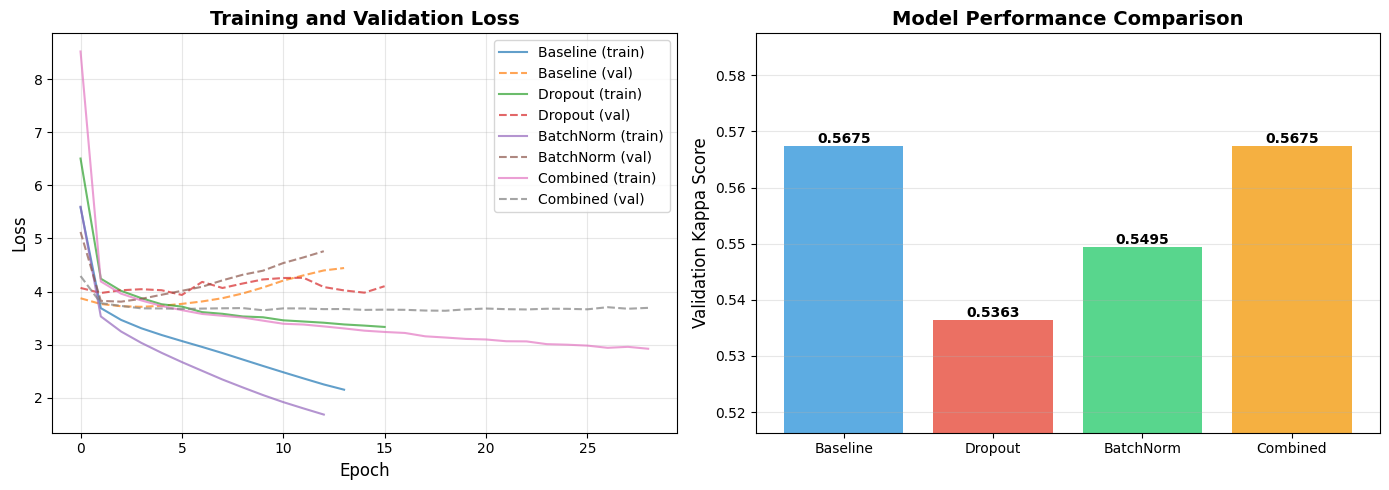

✓ Visualization saved as 'model_comparison.png'


In [ ]:
# Plot training curves and comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training Loss
ax = axes[0]
for name, history in histories.items():
    ax.plot(history.history['loss'], label=f'{name} (train)', alpha=0.7)
    ax.plot(history.history['val_loss'], label=f'{name} (val)', linestyle='--', alpha=0.7)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 2: Model Comparison
ax = axes[1]
model_names = list(results.keys())
kappa_scores = [results[name]['kappa'] for name in model_names]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = ax.bar(model_names, kappa_scores, color=colors, alpha=0.8)
ax.set_ylabel('Validation Kappa Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([min(kappa_scores) - 0.02, max(kappa_scores) + 0.02])
ax.grid(True, axis='y', alpha=0.3)

# Add values on bars
for bar, score in zip(bars, kappa_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'model_comparison.png'")

In [ ]:
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"{'Model':<15} {'Kappa':<12} {'MAE':<10}")
print("-"*60)

for name in model_names:
    print(f"{name:<15} {results[name]['kappa']:<12.4f} {results[name]['mae']:<10.4f}")

best_model_name = max(results, key=lambda x: results[x]['kappa'])
print("\n" + "="*60)
print(f"🏆 Best Model: {best_model_name}")
print(f"   Kappa Score: {results[best_model_name]['kappa']:.4f}")
print(f"   MAE: {results[best_model_name]['mae']:.4f}")
print("="*60)


FINAL RESULTS SUMMARY
Model           Kappa        MAE       
------------------------------------------------------------
Baseline        0.5675       1.4568    
Dropout         0.5363       1.6361    
BatchNorm       0.5495       1.4855    
Combined        0.5675       1.4256    

🏆 Best Model: Baseline
   Kappa Score: 0.5675
   MAE: 1.4568


In [ ]:
print("\n" + "="*60)
print("KEY OBSERVATIONS AND ANALYSIS")
print("="*60)

print("\n1. DROPOUT EFFECT:")
print("   " + "-"*55)
print("   - Randomly drops neurons during training")
print("   - Prevents co-adaptation of features")
print("   - Reduces overfitting")
dropout_improvement = results['Dropout']['kappa'] - results['Baseline']['kappa']
print(f"   - Improvement over baseline: {dropout_improvement:+.4f}")
if dropout_improvement > 0:
    print("   ✓ Dropout successfully reduced overfitting")
else:
    print("   ⚠ Dropout did not improve performance (baseline may already be well-regularized)")

print("\n2. BATCH NORMALIZATION EFFECT:")
print("   " + "-"*55)
print("   - Normalizes layer inputs")
print("   - Reduces internal covariate shift")
print("   - Allows higher learning rates")
print("   - Accelerates convergence")
bn_improvement = results['BatchNorm']['kappa'] - results['Baseline']['kappa']
print(f"   - Improvement over baseline: {bn_improvement:+.4f}")
if bn_improvement > 0:
    print("   ✓ Batch normalization improved training stability")
else:
    print("   ⚠ Batch normalization did not help (may not be needed for this data)")

print("\n3. COMBINED APPROACH (Dropout + BatchNorm):")
print("   " + "-"*55)
print("   - Leverages both regularization techniques")
print("   - BatchNorm stabilizes training")
print("   - Dropout prevents overfitting")
combined_improvement = results['Combined']['kappa'] - results['Baseline']['kappa']
print(f"   - Improvement over baseline: {combined_improvement:+.4f}")
if combined_improvement > 0:
    print("   ✓ Combined approach achieved best results")
else:
    print("   ⚠ Combined approach didn't outperform individual techniques")

print("\n4. ORDINAL REGRESSION APPROACH:")
print("   " + "-"*55)
print("   - Single output node treats risk as continuous")
print("   - Preserves ordinal relationships (5 is between 4 and 6)")
print("   - Custom loss function keeps predictions in valid range")
print("   - Better than treating as 8 independent classes")

print("\n" + "="*60)


KEY OBSERVATIONS AND ANALYSIS

1. DROPOUT EFFECT:
   -------------------------------------------------------
   - Randomly drops neurons during training
   - Prevents co-adaptation of features
   - Reduces overfitting
   - Improvement over baseline: -0.0312
   ⚠ Dropout did not improve performance (baseline may already be well-regularized)

2. BATCH NORMALIZATION EFFECT:
   -------------------------------------------------------
   - Normalizes layer inputs
   - Reduces internal covariate shift
   - Allows higher learning rates
   - Accelerates convergence
   - Improvement over baseline: -0.0180
   ⚠ Batch normalization did not help (may not be needed for this data)

3. COMBINED APPROACH (Dropout + BatchNorm):
   -------------------------------------------------------
   - Leverages both regularization techniques
   - BatchNorm stabilizes training
   - Dropout prevents overfitting
   - Improvement over baseline: -0.0000
   ⚠ Combined approach didn't outperform individual techniques

4

In [ ]:
# Use best model for predictions
best_model_obj = models[best_model_name]

print(f"Generating predictions using {best_model_name} model...")
test_predictions = best_model_obj.predict(X_test_scaled, verbose=0)
test_predictions_rounded = np.clip(np.round(test_predictions), 1, 8).astype(int).flatten()

# Check prediction distribution
print("\nTest Prediction Distribution:")
unique, counts = np.unique(test_predictions_rounded, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Risk Level {val}: {count:5d} ({count/len(test_predictions_rounded)*100:5.1f}%)")

# Create submission file
submission = pd.DataFrame({
    'Id': test_ids,
    'Response': test_predictions_rounded
})
submission.to_csv('submission.csv', index=False)

print(f"\n✓ Submission file created: 'submission.csv'")
print(f"  Total predictions: {len(submission)}")
print(f"  Ready for Kaggle submission!")

# Download the file
from google.colab import files
files.download('submission.csv')
print("\n✓ File downloaded to your computer!")

Generating predictions using Baseline model...

Test Prediction Distribution:
  Risk Level 1:   192 (  1.0%)
  Risk Level 2:   777 (  3.9%)
  Risk Level 3:  1588 (  8.0%)
  Risk Level 4:  2537 ( 12.8%)
  Risk Level 5:  3423 ( 17.3%)
  Risk Level 6:  4453 ( 22.5%)
  Risk Level 7:  4849 ( 24.5%)
  Risk Level 8:  1946 (  9.8%)

✓ Submission file created: 'submission.csv'
  Total predictions: 19765
  Ready for Kaggle submission!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ File downloaded to your computer!
